# Setup

In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from fxvol.data_utils import load_csv
from fxvol.config import CURRENCIES, MODELS, MODEL_NAMES, LOSS_FNS

In [2]:
# Pictures size

plt.rcParams["figure.figsize"] = [15, 8]

# Forecasting results

In [8]:
for currency in CURRENCIES:
    res = load_csv("results/backtest", currency, index_col=0)
    print(currency)
    print(res)
    print("\n")

AUD
                      RMSE       MAE     QLIKE
gb_tree           0.001852  0.001400  0.096114
ols               0.001843  0.001388  0.097797
garch11           0.001889  0.001475  0.100719
har               0.001867  0.001407  0.101005
rolling50         0.001874  0.001386  0.101267
ewma030           0.002202  0.001625  0.137444
elastic_net_1     0.002234  0.001836  0.137446
elastic_net_1e-3  0.002234  0.001836  0.137446
rolling5          0.002135  0.001595  0.138827
naive             0.002349  0.001748  0.188841
ewma080           0.002932  0.002194  0.407253


CHF
                      RMSE       MAE     QLIKE
gb_tree           0.002445  0.001799  0.123896
ols               0.002487  0.001803  0.125830
har               0.002513  0.001821  0.128383
garch11           0.002564  0.001971  0.132923
rolling50         0.002649  0.001926  0.141040
elastic_net_1     0.002856  0.002214  0.168214
elastic_net_1e-3  0.002856  0.002214  0.168214
ewma030           0.002821  0.002029  0.168796
rol

In [4]:
fc_res = []
for currency in CURRENCIES:
    res = load_csv("results/backtest", currency, index_col=0).astype(float)
    res.index.name = "model"
    res["currency"] = currency
    fc_res.append(res)

fc_res = pd.concat(fc_res)

In [5]:
fc_res_mean = fc_res.groupby("model")[LOSS_FNS].mean()
fc_res_mean = fc_res_mean.sort_values(by="QLIKE", ascending=True)

In [6]:
fc_res_mean.style.format("{:.2e}")

,MAE,RMSE,QLIKE
model,,,
gb_tree,1.67e-03,2.32e-03,1.05e-01
ols,1.68e-03,2.30e-03,1.08e-01
har,1.70e-03,2.33e-03,1.11e-01
rolling50,1.71e-03,2.38e-03,1.15e-01
garch11,1.89e-03,2.44e-03,1.19e-01
elastic_net_1,2.00e-03,2.60e-03,1.38e-01
elastic_net_1e-3,2.00e-03,2.60e-03,1.38e-01
ewma030,1.97e-03,2.71e-03,1.51e-01
rolling5,1.98e-03,2.72e-03,1.62e-01


<BarContainer object of 11 artists>

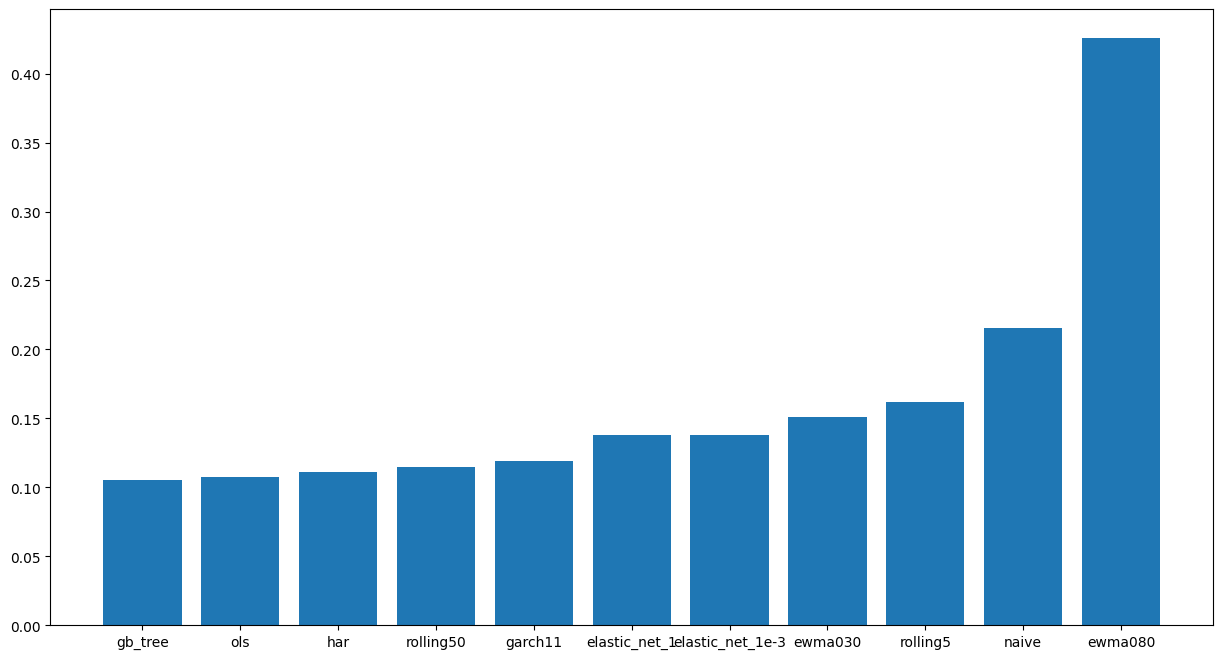

In [7]:
plt.bar(fc_res_mean.index, fc_res_mean["QLIKE"])

In [10]:
qlikes = pd.DataFrame(index=CURRENCIES, columns=MODEL_NAMES)
for currency in CURRENCIES:
    res = load_csv("results/backtest", currency, index_col=0)
    qlikes.loc[currency] = res.loc[MODEL_NAMES, "QLIKE"]

qlikes = qlikes.astype(float)

<Axes: >

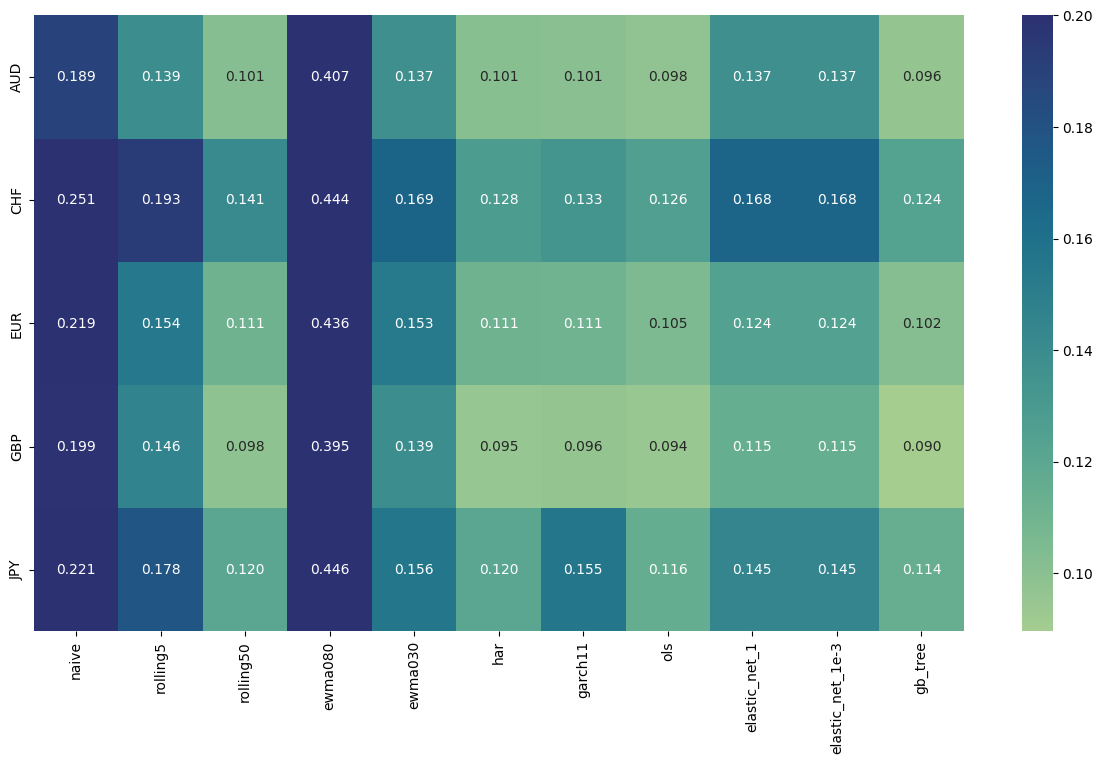

In [12]:
sns.heatmap(qlikes, annot=True, fmt=".3f", cmap="crest", vmax=0.2)

# Volatility targeting results

In [ ]:
metrics = load_csv("results/summary", "metrics", index_col=0)
metrics.index.name = "model"
metrics.sort_values(by="vol_error", inplace=True)
metrics.style.format(
    {
        "ann_return": "{:.1%}",
        "ann_vol": "{:.1%}",
        "vol_error": "{:.2%}",
        "max_dd": "{:.1%}",
        "Sharpe": "{:.2f}",
    }
)

,ann_return,ann_vol,vol_error,Sharpe,max_dd
model,,,,,
elastic_net_1,0.3%,10.0%,0.04%,0.03,-26.8%
elastic_net_1e-3,0.3%,10.0%,0.04%,0.03,-26.8%
gb_tree,-1.4%,10.2%,0.20%,-0.14,-30.9%
garch11,-2.2%,9.7%,0.25%,-0.22,-30.0%
ols,-2.5%,10.5%,0.54%,-0.23,-32.1%
har,-2.1%,10.7%,0.69%,-0.20,-32.8%
rolling50,-3.2%,11.1%,1.13%,-0.29,-36.5%
ewma030,-4.1%,12.1%,2.05%,-0.34,-36.4%
rolling5,-3.4%,12.6%,2.58%,-0.27,-35.5%


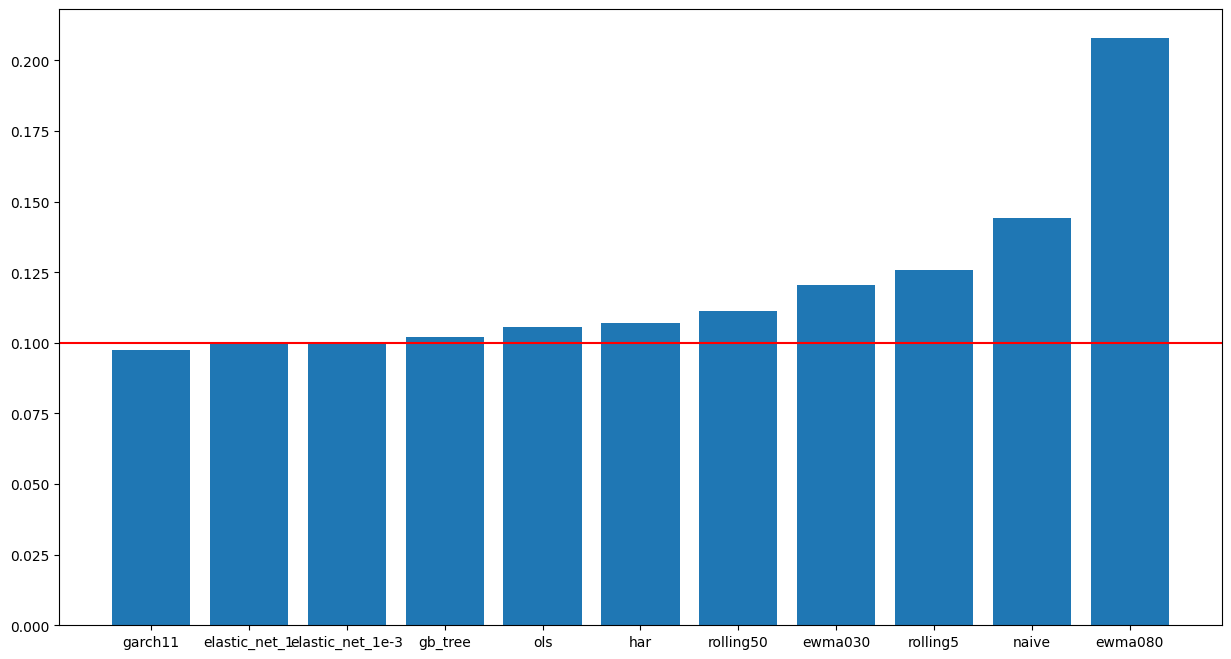

In [43]:
av = metrics['ann_vol'].sort_values()
plt.bar(av.index, av)
plt.axhline(y=0.1, color="r")

# Equity curves

In [44]:
log_rets = load_csv("results/summary", "log_rets")
equity = np.exp(log_rets.cumsum())

In [45]:
models_subset = ["naive", "har", "ols", "elastic_net_1e-3", "gb_tree"]

<Axes: xlabel='Date'>

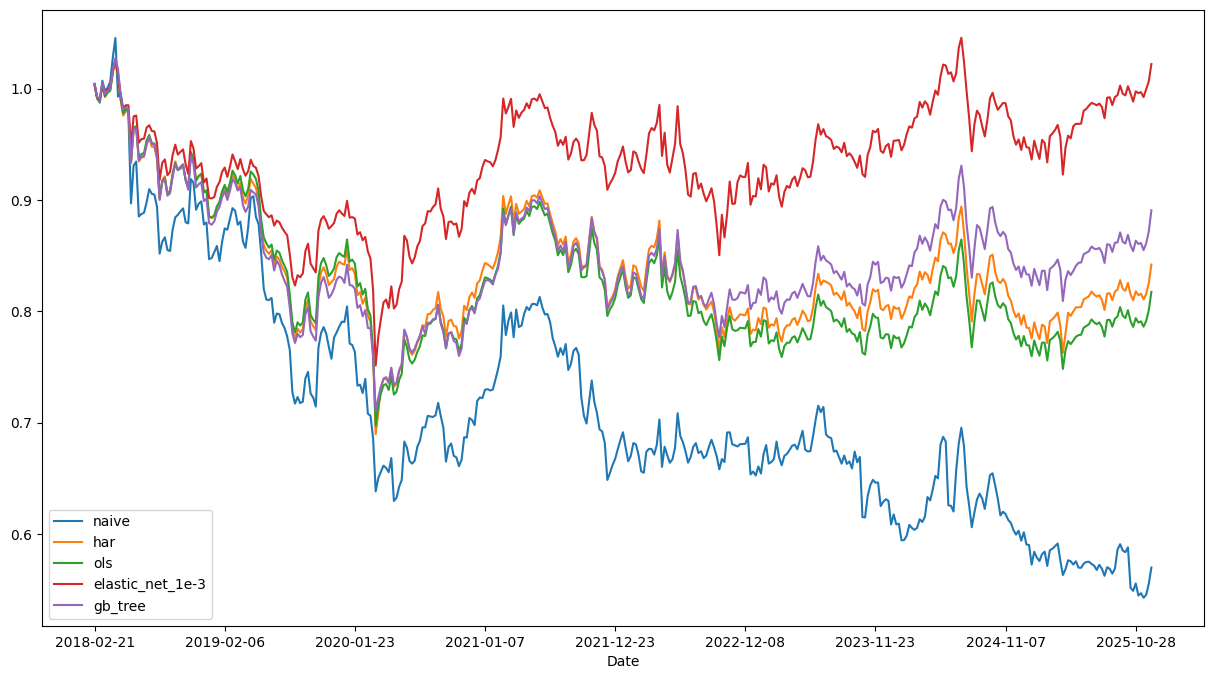

In [46]:
equity[models_subset].plot()